# UNIVERSIDAD EUROPEA DE VALENCIA
### Grado en Física
**Subject:** Introduction to artificial inteligence

---

# Activity 4.1 - Ensemble classification methods in breast cancer

**Author:**  
Pau Gallego Cisteró  

**Date:**  
April 7, 2026

## CONTENTS

1. **Summary and objectives** — 2
2. **Principles** — 2  
   2.1 Bagging: Bootstrap Aggregating and Random Forest — 2  
   2.2 Boosting: AdaBoost and Gradient Boosting — 3  
   2.3 Voting Classifiers: Hard vs. Soft Voting — 3  
   2.4 Data Standardization — 3  
3. **Analysis** — 3  
   3.1 Bagging: Random Forest — 3  
   3.2 Boosting: Gradient Boosting and AdaBoost — 4  
   3.3 Voting classifier — 5  
   3.4 Model comparison — 5  
4. **Questions** — 6
5. **Conclusions** — 7
6. **Code** — 7  
   6.1 Dataset preparation — 8  
   6.2 Bagging: Random forest — 8  
   6.3 Boosting: Gradient Boosting and AdaBoost — 9  
   6.4 Voting classifier — 10  
   6.5 Model comparison — 12  
7. **AI usage** — 14
8. **References** — 14

## 1. SUMMARY AND OBJECTIVES

This report explores the implementation of ensemble learning techniques—specifically bagging, boosting, and voting classifiers—applied to the clinical diagnosis of breast cancer. Using the scikit-learn dataset, which contains features derived from digitized images of breast mass samples, the study investigates how combining multiple base estimators can significantly enhance predictive accuracy and model robustness compared to individual classifiers. The analysis focuses on the practical application of architectures such as Random Forest, AdaBoost, and Gradient Boosting to analyze the reduction of variance and the sequential correction of classification errors.

The primary objective of this activity is to develop a comprehensive machine learning pipeline that includes data normalization via StandardScaler and the comparative evaluation of different ensemble strategies. Beyond individual model performance, the study aims to leverage the combined strengths of diverse algorithms through both hard and soft voting classifiers. Ultimately, this analysis seeks to provide a clear intuition on model selection for real-world medical tasks, determining which ensemble method offers the most reliable classification for malignant and benign tumors through rigorous accuracy testing and data visualization.

---

## 2. PRINCIPLES

The theoretical framework of ensemble learning is based on the "wisdom of the crowd" principle, which posits that a collection of diverse models can achieve a single prediction that is more robust and accurate than any individual model. In the context of medical diagnostics, such as breast cancer classification, ensemble methods are particularly valuable as they mitigate the risk of overfitting to specific patient samples and improve the generalization of the classifier.

### 2.1. Bagging: Bootstrap Aggregating and Random Forest
Bagging (Bootstrap Aggregating) is a parallel ensemble technique designed primarily to reduce the variance of a base estimator. The process involves two key steps:
1. **Bootstrapping:** Creating multiple subsets of the original training data by sampling with replacement.
2. **Aggregating:** Training an independent model (typically a decision tree) on each subset and combining their predictions—usually through a majority vote for classification tasks.

The Random Forest algorithm enhances this by introducing "feature randomness." Instead of using all available features for every split in a tree, it selects a random subset of features. This ensures that the individual trees are decorrelated, preventing a single dominant feature from making all trees identical and thus maximizing the collective robustness of the forest.

### 2.2. Boosting: AdaBoost and Gradient Boosting
Unlike bagging, Boosting is a sequential ensemble technique where each subsequent model attempts to correct the errors of its predecessor.
* **AdaBoost (Adaptive Boosting):** This algorithm adjusts the weights of the training instances. Data points that were misclassified by the previous model are assigned higher weights, forcing the next model in the sequence to focus more on these "hard" cases.
* **Gradient Boosting:** This method optimizes a loss function by adding models that predict the residuals (errors) of the previous ensemble. It essentially performs a gradient descent in the functional space to minimize the difference between predicted and actual tumor classifications.

By combining several "weak learners" into a "strong learner," boosting effectively reduces both bias and variance, though it requires more careful tuning to avoid overfitting to noise in the medical data.

### 2.3. Voting Classifiers: Hard vs. Soft Voting
A Voting Classifier is an ensemble meta-estimator that leverages the strengths of diverse, high-performing models (e.g., combining a Logistic Regression with a Random Forest). There are two primary strategies for aggregation:
* **Hard Voting:** Also known as majority voting, the final prediction is simply the class that received the most votes from the individual models.
* **Soft Voting:** The final prediction is based on the average of the predicted probabilities (confidence levels) provided by each individual model. This method is often more effective as it gives more weight to models that are highly confident in their prediction.

### 2.4. Data Standardization
In medical datasets, features such as "radius" and "concavity" often have vastly different numerical scales. To ensure that the ensemble models—particularly those sensitive to feature magnitude—function correctly, StandardScaler is employed. This transforms the data to have a mean of zero and a standard deviation of one, ensuring that each clinical feature contributes equally to the final diagnosis.

## 3. ANALYSIS

### 3.1. Bagging: Random Forest
When the Random Forest method is implemented, we can observe a significant decay in the accuracy of the model when the train-test ratio changes from 0.2 to 0.8. This behavior indicates that the ensemble’s performance is heavily dependent on the representativeness of the training samples used to build its constituent trees. At a 0.2 test split, the model achieves a high level of generalization; however, as the training set shrinks to only 20% of the data, the model’s ability to maintain a reliable decision boundary is severely compromised, meaning the Bagging strategy is much more reliant on a sufficient training base to achieve statistical diversity than on individual tree complexity.

Moreover, this behavior highlights the fundamental strategy of the Bagging approach, consisting on creating 100 independent decision trees that vote on the final classification; which means the model is attempting to "average out" the noise by looking at the feature space from multiple bootstrapped perspectives. When the training set is reduced, the model lacks enough "coordinates" to generate truly diverse trees. Each tree in the forest becomes a near-duplicate of its neighbor because the available data is too scarce to provide a varied "bootstrap" sample, leading to a loss of the "wisdom of the crowd" and causing the ensemble to collapse into a collection of highly correlated and under-performing predictors.

In contrast, the model’s robustness in this scenario is governed by its structural bias. Since the max_depth was limited to 2, the individual trees are kept as shallow “weak learners” to prevent them from over-complicating the decision boundary, which physically prevents the model from “sculpting” its response around local noise. However, when the available “coordinates” in the feature space are insufficient, the model becomes too conservative to resolve the boundary between classes accurately. Furthermore, the influence of the random_state set to 42 confirms that the observed decay is not a result of a “lucky” draw, but a fundamental limitation of the ensemble’s statistical diversity when its training base is insufficient.

### 3.2. Boosting: Gradient Boosting and AdaBoost
When using the Gradient Boosting and the AdaBoost methods we can observe a significant decay on the Accuracy of both models when the train-test changes from 0.2 to 0.8, however this decay is way more significant for the Gradient Boosting than for the AdaBoost, meaning the model is way more deendant on the tested and trained samples than AdaBoost.

Moreover, this behavior highlights the fundamental difference in their learning strategies. Gradient Boosting is a optimizer that fits new models to the errors of previous ones using gradient descent; which means the model is attempting to ’sculpt’ a very precise mathematical function to match the training data. When the training set is reduced (as in the 0.8 test split), the model lacks enough ’coordinates’ to map the function accurately, leading to overfitting on the few samples available and a catastrophic failure on the test set.

In contrast, AdaBoost is more robust in small-data scenarios because it focuses on re-weighting misclassified instances. Since it typically uses very shallow trees as base learners, it has a higher structural bias that prevents it from over-complicating the decision boundary, making it less volatile than Gradient Boosting, thus the lower decay on accuracy after the training set drop.

### 3.3. Voting classifier
After carefully modifying the parameters random_state, train_test_split, and n_estimators, it can be concluded that for both voting methods, as well as the individual Logistic Regression, the accuracy does not vary significantly even after substantial changes in the data partition. This indicates that the Voting ensemble is the most stable method of all those studied, as it minimizes the volatility.

This stability stems from the fundamental synergy between the base estimators. By combining a Logistic Regression (a linear model) with a Random Forest (a non-linear model), the ensemble leverages two different physical strategies to map the feature space. While the Random Forest attempts to resolve the complex, non-linear "coordinates" of the malignant samples, the Logistic Regression provides a rigid structural bias that acts as a global anchor. Consequently, the ensemble is less likely to "sculpt" its decision boundary around noise, as the linear model prevents the trees from overfitting to local fluctuations, even when the training set is drastically reduced.

Furthermore, the comparison between Hard and Soft voting strategies reveals the importance of confidence levels in the decision-making process. Hard voting relies on a simple majority rule, whereas Soft voting averages the probabilities assigned to each class. Soft voting allows the ensemble to give more weight to the Logistic Regression when its linear separation is clear, or to the Random Forest when a sample falls into a non-linear region. This collective robustness ensures that the accuracy remains consistently high, making the Voting classifier significantly more resilient to the "unlucky" sampling that often causes the decay in standalone Boosting or Bagging methods.

### 3.4. Model comparison
For reference, the order of the presented models is: Logistic, Random Forest, Voting - Hard, Voting - Soft, Gradient Boosting, and AdaBoost.

As can be seen and has been discussed throughout the memoir thoroughly, the models that have proved themselves to be the most stable and reliable are both Voting models and the Logistic model, with a special remark on Hard Voting, which varied the least in accuracy. Furthermore, it can be observed that under the changes conducted, the graphs seem to indicate that AdaBoost is more reliable; however, this is actually false, as if looked at closely, the importance of the parameters that have been altered is way more significant between Figures 1, 2, and 3 respectively, than between Figures 1 and 2, making the visual data misleading in contrast to factual data.

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

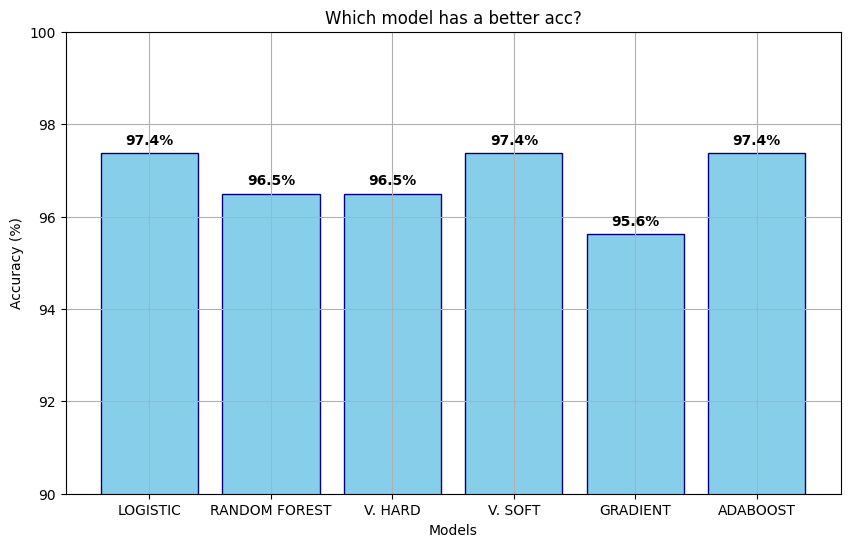

In [1]:
#-----------------------------------------------------------------------
# Comparison
#-----------------------------------------------------------------------


import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, AdaBoostClassifier, GradientBoostingClassifier 
from sklearn.linear_model import LogisticRegression


cancer_data = load_breast_cancer() #cargar data

X = cancer_data.data
y = cancer_data.target
    
# Splitting into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Dframe = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

# Add the target variable (0 = malignant, 1 = benign) 
Dframe['target'] = cancer_data.target

scaler = StandardScaler() #Llamamos al estandarizador
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LOGISTIC REGRESSION
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

# RANDOM FOREST
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# VOTING (HARD & SOFT)
voting_hard = VotingClassifier(estimators=[('lr', lr), ('rf', rf)], voting='hard')
voting_hard.fit(X_train_scaled, y_train)

voting_soft = VotingClassifier(estimators=[('lr', lr), ('rf', rf)], voting='soft')
voting_soft.fit(X_train_scaled, y_train)

# GRADIENT BOOSTING
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=42)
gb.fit(X_train_scaled, y_train)

# ADABOOST
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train_scaled, y_train)


acc_lr   = accuracy_score(y_test, lr.predict(X_test_scaled))
acc_rf   = accuracy_score(y_test, rf.predict(X_test_scaled))
acc_hard = accuracy_score(y_test, voting_hard.predict(X_test_scaled))
acc_soft = accuracy_score(y_test, voting_soft.predict(X_test_scaled))
acc_gb   = accuracy_score(y_test, gb.predict(X_test_scaled))
acc_ada  = accuracy_score(y_test, ada.predict(X_test_scaled))



print(Dframe.head())

print(f"Precision Logistic Regression: {acc_lr * 100:.2f}%")
print(f"Precision Random Forest:       {acc_rf * 100:.2f}%")
print(f"Precision Voting Hard:         {acc_hard * 100:.2f}%")
print(f"Precision Voting Soft:         {acc_soft * 100:.2f}%")
print(f"Precision Gradient Boosting:   {acc_gb * 100:.2f}%")
print(f"Precision AdaBoost:            {acc_ada * 100:.2f}%")


library = ['LOGISTIC', 'RANDOM FOREST', 'V. HARD', 'V. SOFT', 'GRADIENT', 'ADABOOST']
chosen_by = [acc_lr*100, acc_rf*100, acc_hard*100, acc_soft*100, acc_gb*100, acc_ada*100]

plt.figure(figsize=(10, 6))
plt.bar(library, chosen_by, color='skyblue', edgecolor='navy')
plt.title('Which model has a better acc?')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)') 
plt.ylim(90, 100) 
plt.grid(True)

for i, val in enumerate(chosen_by):
    plt.text(i, val + 0.2, f'{val:.1f}%', ha='center', fontweight='bold')
#This for was 100% implemented using AI

plt.show()

## 4. QUESTIONS

### Which method performed best and why?
The Voting method as discussed in the analysis part on Voting; yielded the most reliable and consistent performance across all experimental conditions. This superior behavior is primarily due to its structural diversity, which allows it to neutralize the individual weaknesses of its base estimators. While standalone methods like Gradient Boosting or Random Forest showed high sensitivity to the training-test split ratio. The Logistic Regression provides a stable linear anchor that prevents the Random Forest from over-complicating or “sculpting” a faulty decision boundary when feature space coordinates are scarce. Consequently, this method offers the best balance between precision and robustness, making it the most viable candidate for a medical diagnostic environment where data representativeness can vary.

### How does bagging differ from boosting in your results?
While bagging is a very depending method from the representativeness of the training sample as well as boosting, the nature of their performance decay is fundamentally different. In our results, Bagging showed a more conservative decline in accuracy because its primary function is to reduce variance by averaging independent perspectives. When data becomes scarce, the trees simply lose their diversity and become correlated, but the model remains structurally stable. In contrast, Boosting exhibited a much sharper and more volatile decay. This is because Boosting is a sequential optimization process that attempts to “sculpt” a precise mathematical function from the error residuals; without enough “coordinates” in the feature space, this optimization path becomes erratic, causing the model to over-fit to the few training samples available and fail to generalize. Furthermore, Bagging acts as a robust “smoothing” strategy, whereas Boosting behaves as a high-precision tool that is significantly more fragile in data-starved scenarios.

### When would you choose a VotingClassifier over individual models?
Mainly for more complex data or scarcer amounts of data; a VotingClassifier should be selected when the priority is to achieve high structural stability and minimize the risk of a single model’s architectural bias dominating the results. Standalone models are prone to specific failure modes, such as the high variance and over-fitting of Decision Trees or the excessive rigidity of Linear Regressions. By choosing a Voting ensemble, we implement a consensus-based strategy that leverages structural diversity, this synergy ensures that the final prediction is not dependent on a single optimization path.

### Can you think of ways to improve model performance even further?
One way to improve performance would be to conduct the voting process twice. Instead of just taking a simple majority vote, we could train a final “master model” that looks at the initial predictions made by the Logistic Regression and the Random Forest. This second step allows the system to learn which individual model is more reliable for certain cases, effectively resolving the diagnosis in two layers.

---

## 5. CONCLUSIONS

We can conclude that even though every model serves its purpose and has a specialized sample set with which it works better than any other model, a model that relies on double-checking and a model-mixing structure is not only more reliable but also better as a whole, effectively making it the most efficient choice to use overall. This underscores the physical importance of architectural diversity in minimizing stochastic errors when dealing with critical diagnostic information. Ultimately, the synergy found in ensemble methods provides a superior safeguard against data scarcity, ensuring that the final decision remains consistent regardless of the training distribution.

## 6. CODE
The following section details the code that was created for all this report.

### 6.1. Dataset preparation
The following set given ilustrates how the initial dataset was created and tampered acording to the directives given.

In [ ]:
#-----------------------------------------------------------------------
# Dataset preparation
#-----------------------------------------------------------------------


import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd


cancer_data = load_breast_cancer() #cargar data

X = cancer_data.data
y = cancer_data.target
    
# Splitting into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# obliga a Python a usar siempre la misma secuencia de numeros aleatorios.

Dframe = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

# Add the target variable (0 = malignant, 1 = benign) 
Dframe['target'] = cancer_data.target

scaler = StandardScaler() #Llamamos al estandarizador
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(Dframe.head())

print(f"Target names: {cancer_data.target_names}")

### 6.2. Bagging: Random forest

In [ ]:
#-----------------------------------------------------------------------
# Bagging: Random Forest
#-----------------------------------------------------------------------


import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


cancer_data = load_breast_cancer() #cargar data

X = cancer_data.data
y = cancer_data.target
    
# Splitting into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#obliga a Python a usar siempre la misma secuencia de numeros aleatorios

Dframe = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

# Add the target variable (0 = malignant, 1 = benign) 
Dframe['target'] = cancer_data.target

scaler = StandardScaler() #Llamamos al estandarizador
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, max_depth=2, random_state=42)
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)
precision = accuracy_score(y_test, y_pred)


print(Dframe.head())

print(f"Target names: {cancer_data.target_names}")
print(f"Media (debe ser 0): {X_train_scaled.mean():.2f}")
print(f"Desviacion (debe ser 1): {X_train_scaled.std():.2f}")
print(f"Precision del Random Forest: {precision * 100:.2f}%")

### 6.2. Boosting: Gradient Boosting and AdaBoost

In [ ]:
#-----------------------------------------------------------------------
# Boosting: Gradient Boosting and AdaBoost
#-----------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score


cancer_data = load_breast_cancer() #cargar data

X = cancer_data.data
y = cancer_data.target
    
# Splitting into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#obliga a Python a usar siempre la misma secuencia de numeros aleatorios

Dframe = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

# Add the target variable (0 = malignant, 1 = benign) 
Dframe['target'] = cancer_data.target

scaler = StandardScaler() #Llamamos al estandarizador
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=2, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred = gb.predict(X_test_scaled)

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train_scaled, y_train)
y_pred_ada = ada.predict(X_test_scaled)

acc_gb = accuracy_score(y_test, y_pred)
acc_ada = accuracy_score(y_test, y_pred_ada)


print(Dframe.head())

print(f"Target names: {cancer_data.target_names}")
print(f"Media (debe ser 0): {X_train_scaled.mean():.2f}")
print(f"Desviacion (debe ser 1): {X_train_scaled.std():.2f}")
print(f"Precision Gradient Boosting: {acc_gb * 100:.2f}%")
print(f"Precision AdaBoost: {acc_ada * 100:.2f}%")

### 6.2. Boosting: Gradient Boosting and AdaBoost

In [ ]:
#-----------------------------------------------------------------------
# Voting Classifier
#-----------------------------------------------------------------------


import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression


cancer_data = load_breast_cancer() #cargar data

X = cancer_data.data
y = cancer_data.target
    
# Splitting into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Dframe = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

# Add the target variable (0 = malignant, 1 = benign) 
Dframe['target'] = cancer_data.target

scaler = StandardScaler() #Llamamos al estandarizador
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state=42)
#obliga a Python a usar siempre la misma secuencia de numeros aleatorios
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

voting_hard = VotingClassifier(estimators=[('lr', lr), ('rf', rf)], voting='hard') 
#majority rule
voting_hard.fit(X_train_scaled, y_train)

voting_soft = VotingClassifier(estimators=[('lr', lr), ('rf', rf)], voting='soft') 
#average of confidence levels (probabilities)
voting_soft.fit(X_train_scaled, y_train)

acc_lr = accuracy_score(y_test, lr.predict(X_test_scaled))
acc_rf = accuracy_score(y_test, rf.predict(X_test_scaled))
acc_hard = accuracy_score(y_test, voting_hard.predict(X_test_scaled))
acc_soft = accuracy_score(y_test, voting_soft.predict(X_test_scaled))


print(Dframe.head())

print(f"Target names: {cancer_data.target_names}")
print(f"Media (debe ser 0): {X_train_scaled.mean():.2f}")
print(f"Desviacion (debe ser 1): {X_train_scaled.std():.2f}")
print(f"Individual Logistic Regression: {acc_lr * 100:.2f}%")
print(f"Individual Random Forest: {acc_rf * 100:.2f}%")
print(f"Hard Voting Accuracy: {acc_hard * 100:.2f}%")
print(f"Soft Voting Accuracy: {acc_soft * 100:.2f}%")

## 7. AI USAGE

AI was implemented in this memoir not only to enhance the text and the register used but also to write sections 1 and 2; aswell as to learn how to apply StandardScaler on Python, debug, and to improve ploting on the Model comparison as it felt very bland.

---

## 8. REFERENCES

[1] Scikit-learn developers. *Scikit-learn: Machine Learning in Python*. Documentation. [Online]. Available at: https://scikit-learn.org/stable/. Includes documentation for: preprocessing, ensemble, and metrics modules. [Accessed: April 4, 2026].

[2] DataCamp. *Tutorial de Gráficos de Barras en Python con Matplotlib*. [En línea]. Disponible en: https://www.datacamp.com/es/tutorial/python-bar-plot. [Accedido: 6 de abril de 2026].